In [4]:
import sys
import os
parent_directory = os.path.dirname(os.getcwd())
src_directory = os.path.join(parent_directory, 'src')
sys.path.append(src_directory)
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from nn import FunctionModel, save_model, load_model
import copy
import matplotlib.pyplot as plt
from model_training import train_resample,pinn_loss,build_rightside,train_pinn


In [5]:
ndim = 3
gamma = 0.2
kbt = .1
lam = 10
eta = gamma*kbt
omega = gamma
sigma = 1/0.3

args = {
        "ndim": ndim,
        "gamma": gamma,
        "kbt": kbt,
        "lam": lam,
        "eta": eta,
        "omega": omega
    }

print(args)

def dU_func(x):
    dU = torch.zeros_like(x)
    dU[:,0] = 4*(x[:,0]**2-1)*x[:,0]
    dU[:,1:] = x[:,1:]/sigma**2
    return dU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model and configuration
model_file = f'./model/gamma{gamma}_kbt{kbt}.pth'
config_file = f'./config/gamma{gamma}_kbt{kbt}.txt'
q = load_model(model_file,config_file)

model_file = f'./model/gamma{gamma}_kbt{kbt}_pinn.pth'
config_file = f'./config/gamma{gamma}_kbt{kbt}_pinn.txt'
q_pinn = load_model(model_file,config_file)

model_file = f'./model/gamma{gamma}_kbt{kbt}_adaptive_false.pth'
config_file = f'./config/gamma{gamma}_kbt{kbt}_adaptive_false.txt'
q_adaptive_false = load_model(model_file,config_file)




q.to(device=device)
q_pinn.to(device=device)
q_adaptive_false.to(device=device)

valid_sample = 10**6

valid_xm1 = torch.randn(size=(valid_sample,ndim-1),dtype=torch.float32)*sigma*np.sqrt(kbt)
valid_x1 = (torch.rand(size=(int(valid_sample),1),dtype=torch.float32))*2-1
valid_x = torch.concatenate((valid_x1,valid_xm1),dim=1)

valid_v = torch.randn(size=(valid_sample,ndim),dtype = torch.float32)*np.sqrt(kbt)
#data = torch.cat((x.repeat_interleave(Nv_sample,dim=0),v.repeat(Nx_sample,1)),dim=1)
valid_data = torch.cat((valid_x,valid_v),dim=1)
valid_w = torch.ones(size=(valid_data.shape[0],1),device = device,dtype = torch.float32)
valid_w = valid_w/torch.sum(valid_w)

{'ndim': 3, 'gamma': 0.2, 'kbt': 0.1, 'lam': 10, 'eta': 0.020000000000000004, 'omega': 0.2}
Configuration loaded from ./config/gamma0.2_kbt0.1.txt
Model loaded from ./model/gamma0.2_kbt0.1.pth
Configuration loaded from ./config/gamma0.2_kbt0.1_pinn.txt
Model loaded from ./model/gamma0.2_kbt0.1_pinn.pth
Configuration loaded from ./config/gamma0.2_kbt0.1_adaptive_false.txt
Model loaded from ./model/gamma0.2_kbt0.1_adaptive_false.pth


In [6]:
xmin, xmax = -1, 1
vmin, vmax = -3*np.sqrt(kbt), 3*np.sqrt(kbt)
dx = 0.0005
dv = 0.01*np.sqrt(kbt)
Nx = int((xmax - xmin) / dx)
Nv = int((vmax - vmin) / dv)


Ncol = Nx - 1
Nrow = Nv + 1
x = np.linspace(xmin, xmax, Nx + 1)
x=x.astype(np.float32)
v = np.linspace(vmin, vmax, Nv + 1)

if Ncol == Nx - 1:
    xcal = x[1:-1]
else:
    xcal = x

if Nrow == Nv - 1:
    vcal = v[1:-1]
else:
    vcal = v


X, V = np.meshgrid(xcal, vcal)
# print(X.shape, V)

points = np.array([X.reshape(-1), V.reshape(-1)]).T.astype(np.float32)
'''
c = np.arange(len(points))
plt.scatter(points[:, 0], points[:, 1], c=c)
plt.colorbar()
plt.show()
'''
N_matrix = Nrow * Ncol
ddd = torch.zeros((len(points),2*ndim),dtype=torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(points)

xxm1 = torch.randn(size=(1,ndim-1))*np.sqrt(kbt)*sigma
vvm1 = torch.randn(size=(1,ndim-1))*np.sqrt(kbt)
ddd[:,(ndim+1):] = vvm1
ddd[:,1:ndim] = xxm1
ddd = ddd.to(device)
qqq = q(ddd).squeeze().to('cpu').detach()





In [7]:
fd = np.loadtxt(f'./model/fd_g{gamma}_kbt{kbt}.txt')
q0 = np.loadtxt(f'./model/fd_kbt{kbt}_q0.txt')
q_simulation = np.loadtxt('./model/q_s_1d.txt')

In [8]:
qmean = np.zeros_like(q0)
NNN = 10000
ddd = torch.zeros(size=(NNN,2*ndim),dtype=torch.float32)
for i in range(qmean.shape[0]):
    
    ddd[:,ndim:] = torch.randn(size=(NNN,ndim),dtype=torch.float32)*np.sqrt(kbt)
    ddd[:,1:ndim] = torch.randn(size=(NNN,ndim-1),dtype=torch.float32)*np.sqrt(kbt)*sigma
    ddd[:,0] = xcal[i]*torch.ones_like(ddd[:,0])
    qqq = q(ddd.to(device))
    qmean[i] = qqq.mean().item()



In [9]:
ddd = torch.zeros((len(points),2*ndim),dtype=torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(points)

xxm1 = torch.randn(size=(1,ndim-1))*np.sqrt(kbt)*sigma
vvm1 = torch.randn(size=(1,ndim-1))*np.sqrt(kbt)
ddd[:,(ndim+1):] = vvm1
ddd[:,1:ndim] = xxm1
ddd = ddd.to(device)
qqq = q(ddd).squeeze().to('cpu').detach()
qqq_pinn = q_pinn(ddd).squeeze().to('cpu').detach()
qqq_adaptive_false = q_adaptive_false(ddd).squeeze().to('cpu').detach()

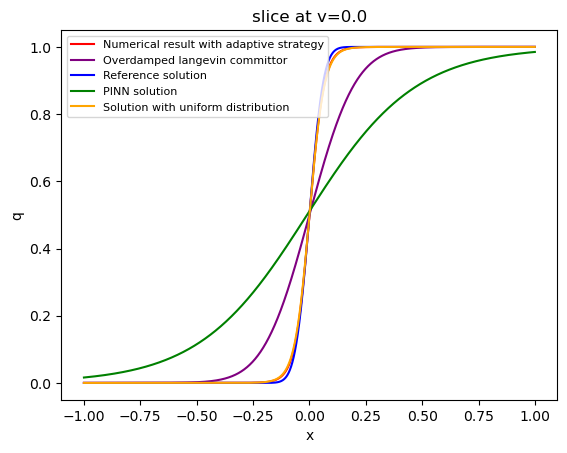

In [7]:
vslice = 0*vmax
Q = qqq.reshape(X.shape)
Q_pinn = qqq_pinn.reshape(X.shape)
Qfd = fd[:,2].reshape(X.shape)
Q_adaptive_false= qqq_adaptive_false.reshape(X.shape)
#plt.plot(xcal[::10], Q[int((vslice-vmin)/dv), ::10]-Qfd[int((vslice-vmin)/dv), ::10])
#plt.plot(xcal[:], Q[int((vslice-vmin)/dv), :]-Qfd[int((vslice-vmin)/dv), :])
plt.plot(xcal[:], Q[int((vslice-vmin)/dv), :],'r',label = 'Numerical result with adaptive strategy')
plt.plot(xcal[:], q0,'purple',label = 'Overdamped langevin committor')
#plt.plot(xcal[:], qmean,label = 'Average over velocity')
plt.plot(xcal[:],Qfd[int((vslice-vmin)/dv), :],'b',label='Reference solution')
plt.plot(xcal[:],Q_pinn[int((vslice-vmin)/dv), :],'g',label='PINN solution')
plt.plot(xcal[:],Q_adaptive_false[int((vslice-vmin)/dv), :],'orange',label='Solution with uniform distribution')
#plt.plot(xcal, Q[int((vslice-vmin)/dv), :])
plt.xlabel('x')
plt.ylabel('q')
plt.legend(loc = 'upper left',fontsize=8)
plt.title(f'slice at v={vslice}')
plt.show()

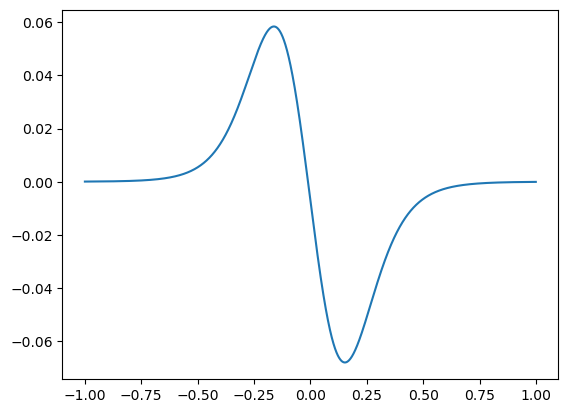

In [24]:
plt.plot(xcal[:], Q_pinn[int((vslice-vmin)/dv), :]-Qfd[int((vslice-vmin)/dv), :])
plt.show()

In [13]:
NN = 1000
vvms = torch.randn(size=(NN,ndim-1),dtype = torch.float32,device=device).to(device)*np.sqrt(kbt)
xxms = torch.randn(size=(NN,ndim-1),dtype = torch.float32,device=device).to(device)*sigma*np.sqrt(kbt)

In [11]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)

l2_loss = 0
l1_loss = 0
linf_loss = 0
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        qqq = q(ddd).squeeze().to('cpu').detach().numpy() 
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=qqq)  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'committor at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])

        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        l2_loss += np.sum((qqq-fd[:,2])**2*ppp)
        l1_loss += np.sum(np.abs(qqq-fd[:,2])*ppp)
        linf_loss = np.max((np.max(np.abs(qqq-fd[:,2])),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn

print(f'Error for solution with adaptive strategy: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')




NameError: name 'vvms' is not defined

Error in callback <function flush_figures at 0x000001F6E6A45120> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
(1201399,) (1201399,)
Pinn loss for solution with adaptive strategy: 
l2 loss: 0.0035947348905676804, l1 loss: 8.516230051601497e-05, linf loss: 0.4446355998516083


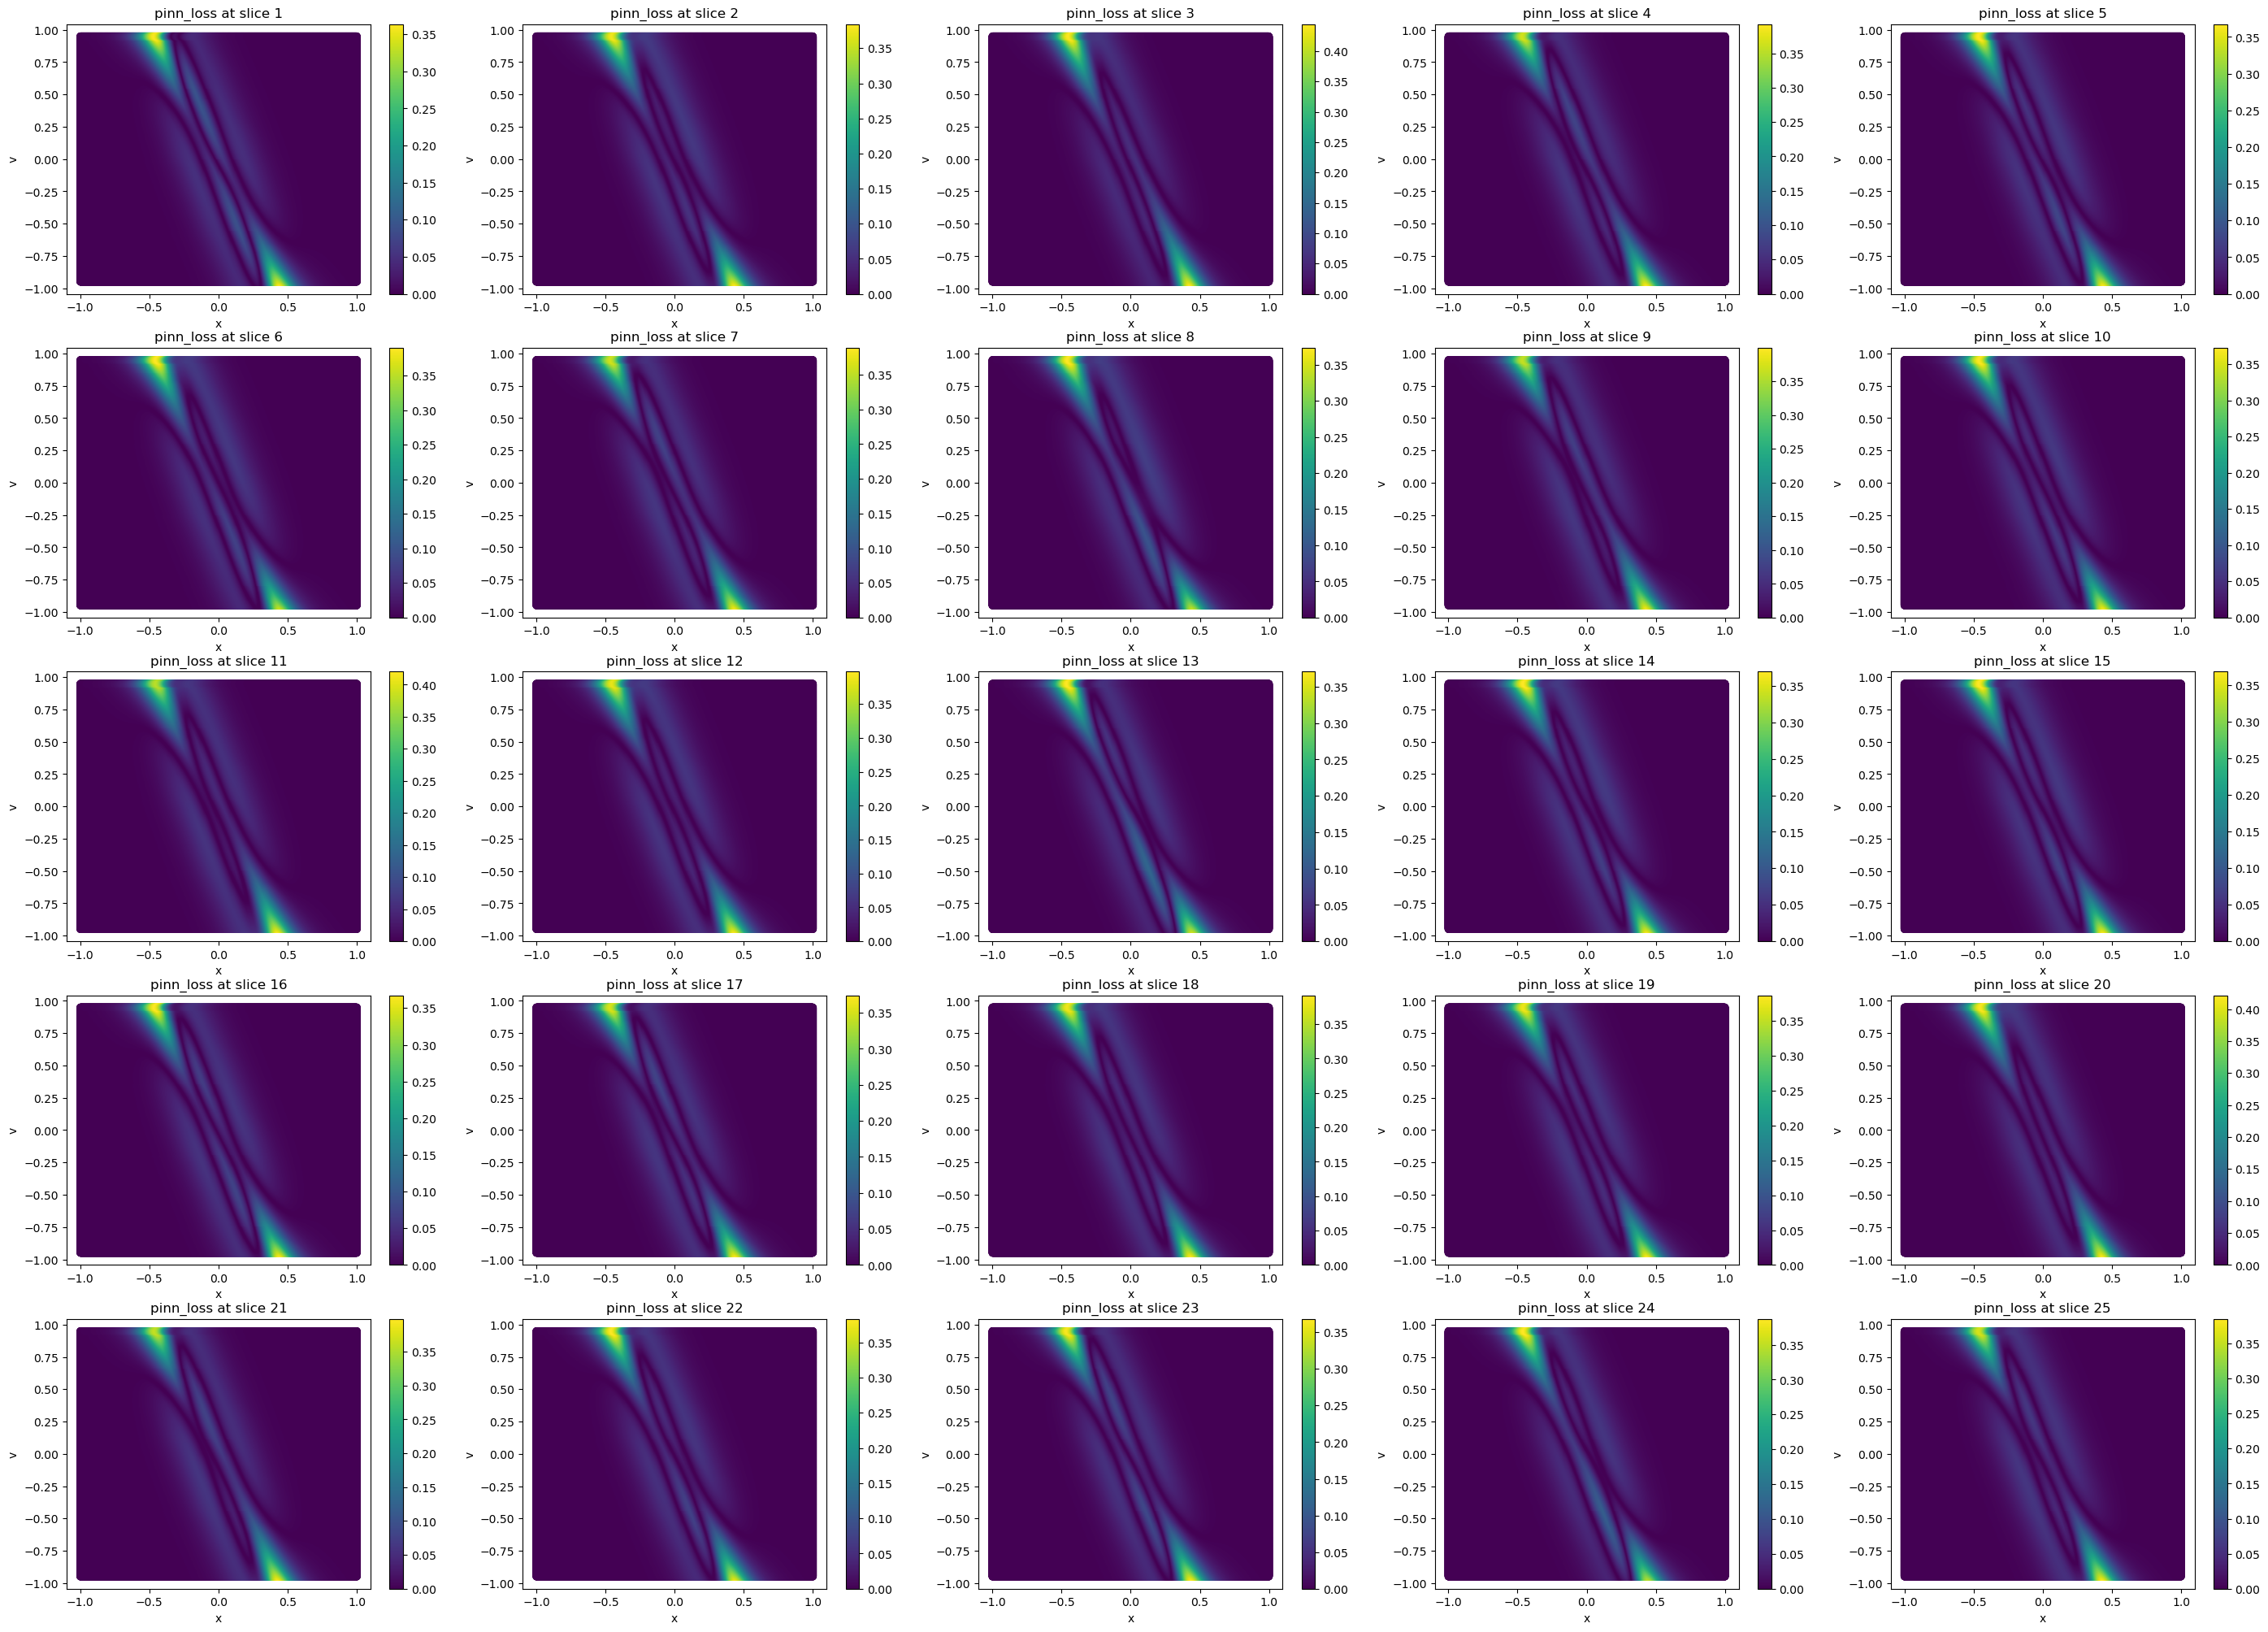

In [ ]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        qqq = q(ddd).squeeze().to('cpu').detach().numpy() 
        dU1 = dU_func(ddd[:,:ndim])
        ddd.requires_grad_(True)
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args).squeeze().detach().cpu().numpy()
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=np.abs(pinn_l))  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'pinn_loss at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])
        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        print(ppp.shape,pinn_l.shape)
        l2_loss += np.sum((pinn_l)**2*ppp)
        l1_loss += np.sum(np.abs(pinn_l)*ppp)
        linf_loss = np.max((np.max(np.abs(pinn_l)),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn

print(f'Pinn loss for solution with adaptive strategy: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')


Error for solution with Pinn: 
l2 loss: 0.027976825682799196, l1 loss: 0.02494593828193694, linf loss: 0.7269640724403863


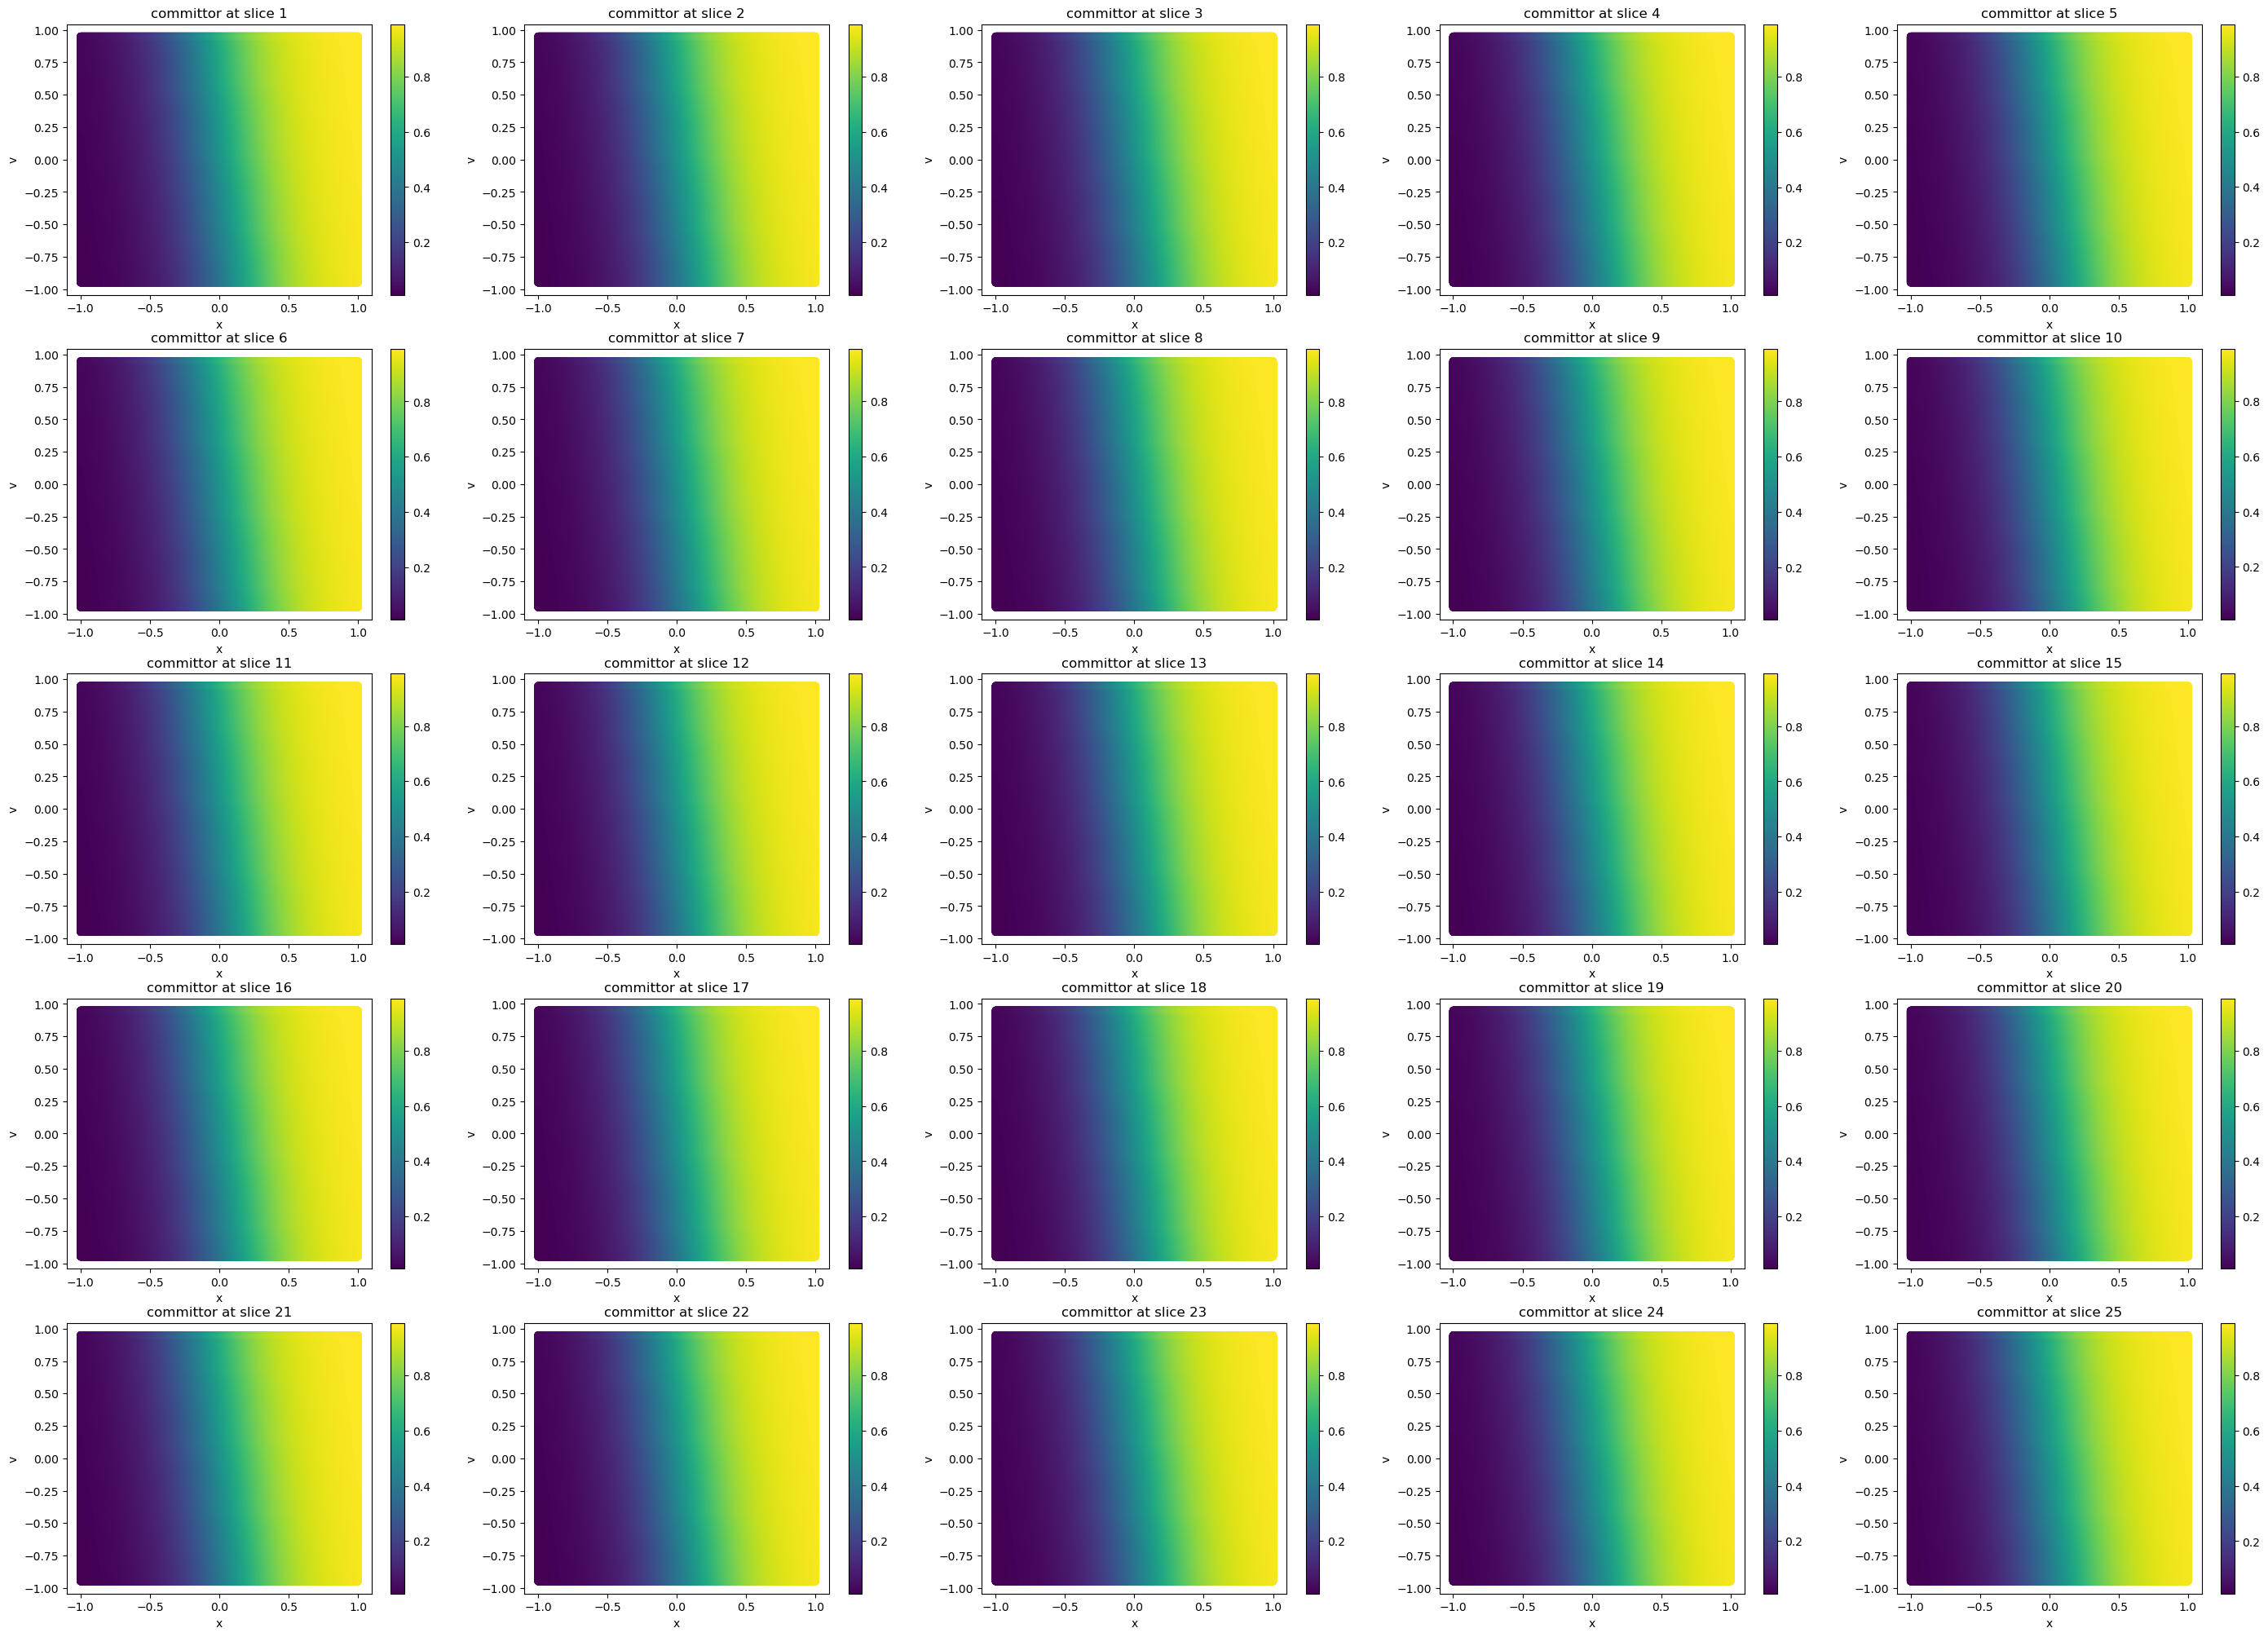

In [14]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        qqq = q_pinn(ddd).squeeze().to('cpu').detach().numpy() 
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=qqq)  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'committor at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])
        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        l2_loss += np.sum((qqq-fd[:,2])**2*ppp)
        l1_loss += np.sum(np.abs(qqq-fd[:,2])*ppp)
        linf_loss = np.max((np.max(np.abs(qqq-fd[:,2])),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn

print(f'Error for solution with Pinn: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')



Pinn loss for solution with Pinn: 
l2 loss: 0.021935976398801228, l1 loss: 9.423742380992005e-05, linf loss: 0.4446355998516083


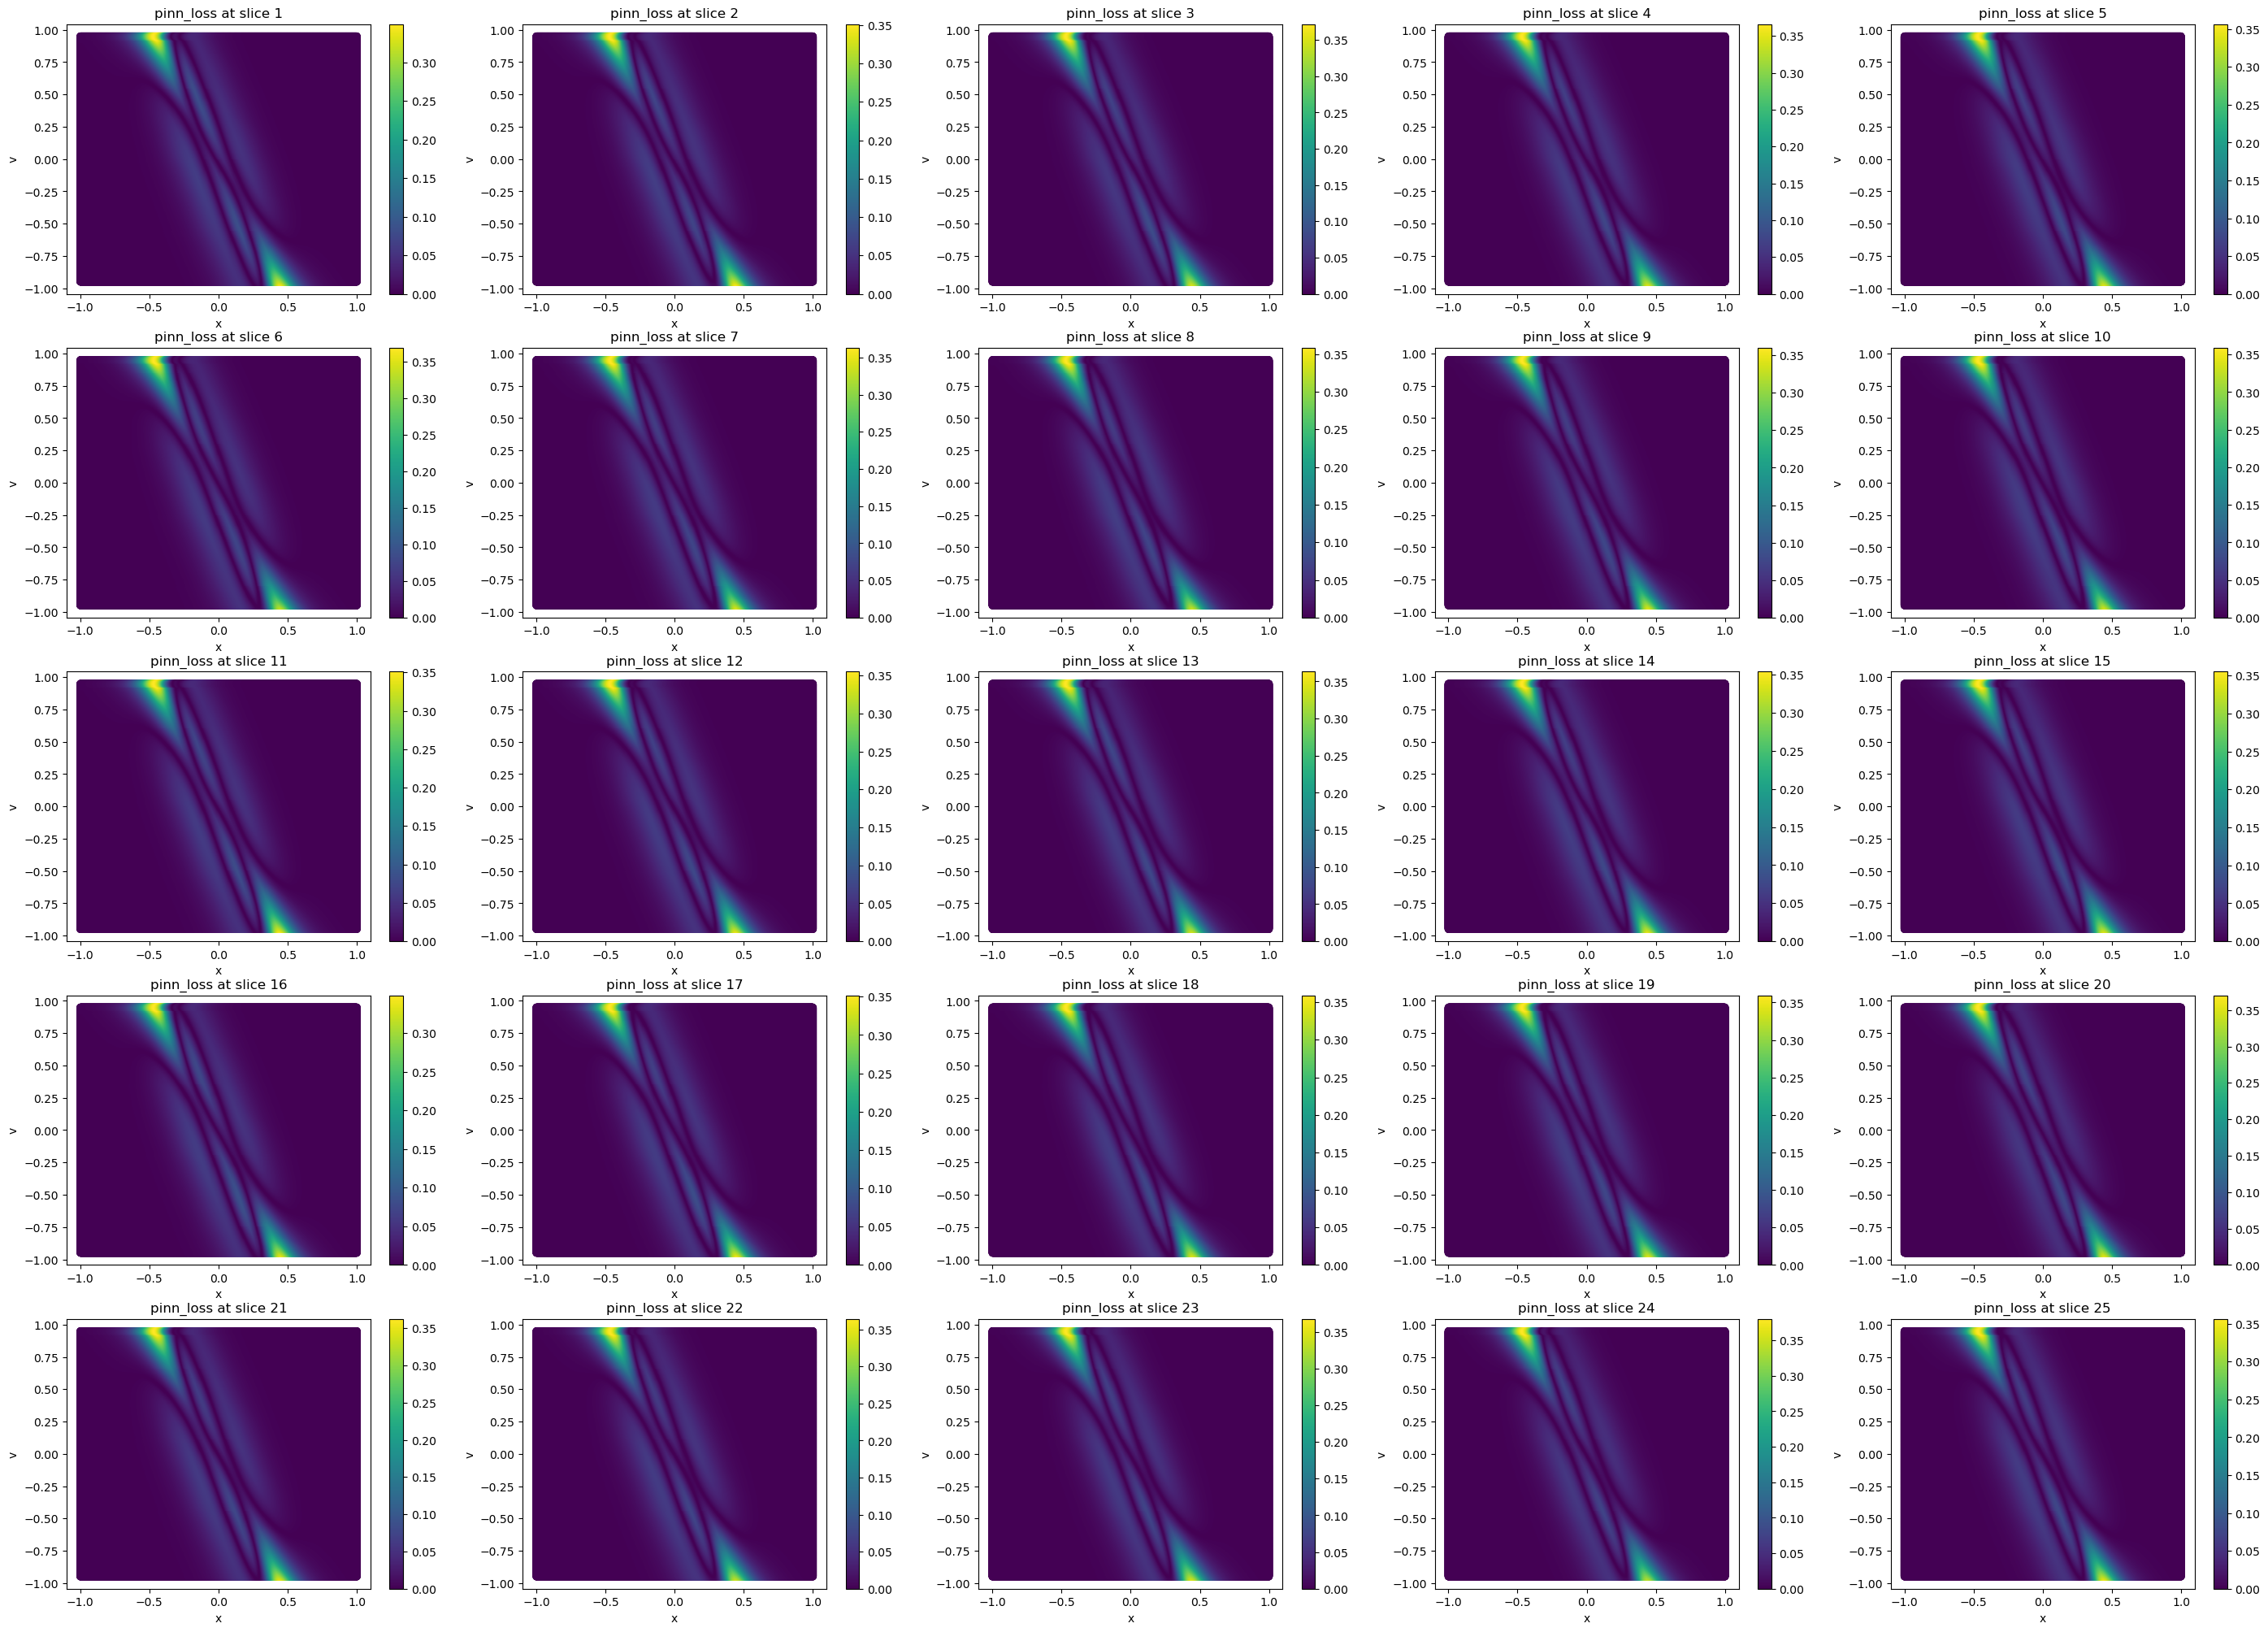

In [ ]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        qqq = q(ddd).squeeze().to('cpu').detach().numpy() 
        dU1 = dU_func(ddd[:,:ndim])
        ddd.requires_grad_(True)
        pinn_l = pinn_loss(q_pinn(ddd),ddd,dU1,args).squeeze().detach().cpu().numpy()
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=np.abs(pinn_l))  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'pinn_loss at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])
        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        l2_loss += np.sum((pinn_l)**2*ppp)
        l1_loss += np.sum(np.abs(pinn_l)*ppp)
        linf_loss = np.max((np.max(np.abs(pinn_l)),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn
print(f'Pinn loss for solution with Pinn: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
Error for solution with uniform distribution: 
l2 loss: 0.029623076611591182, l1 loss: 3.149821794509593e-05, linf loss: 0.4446355998516083


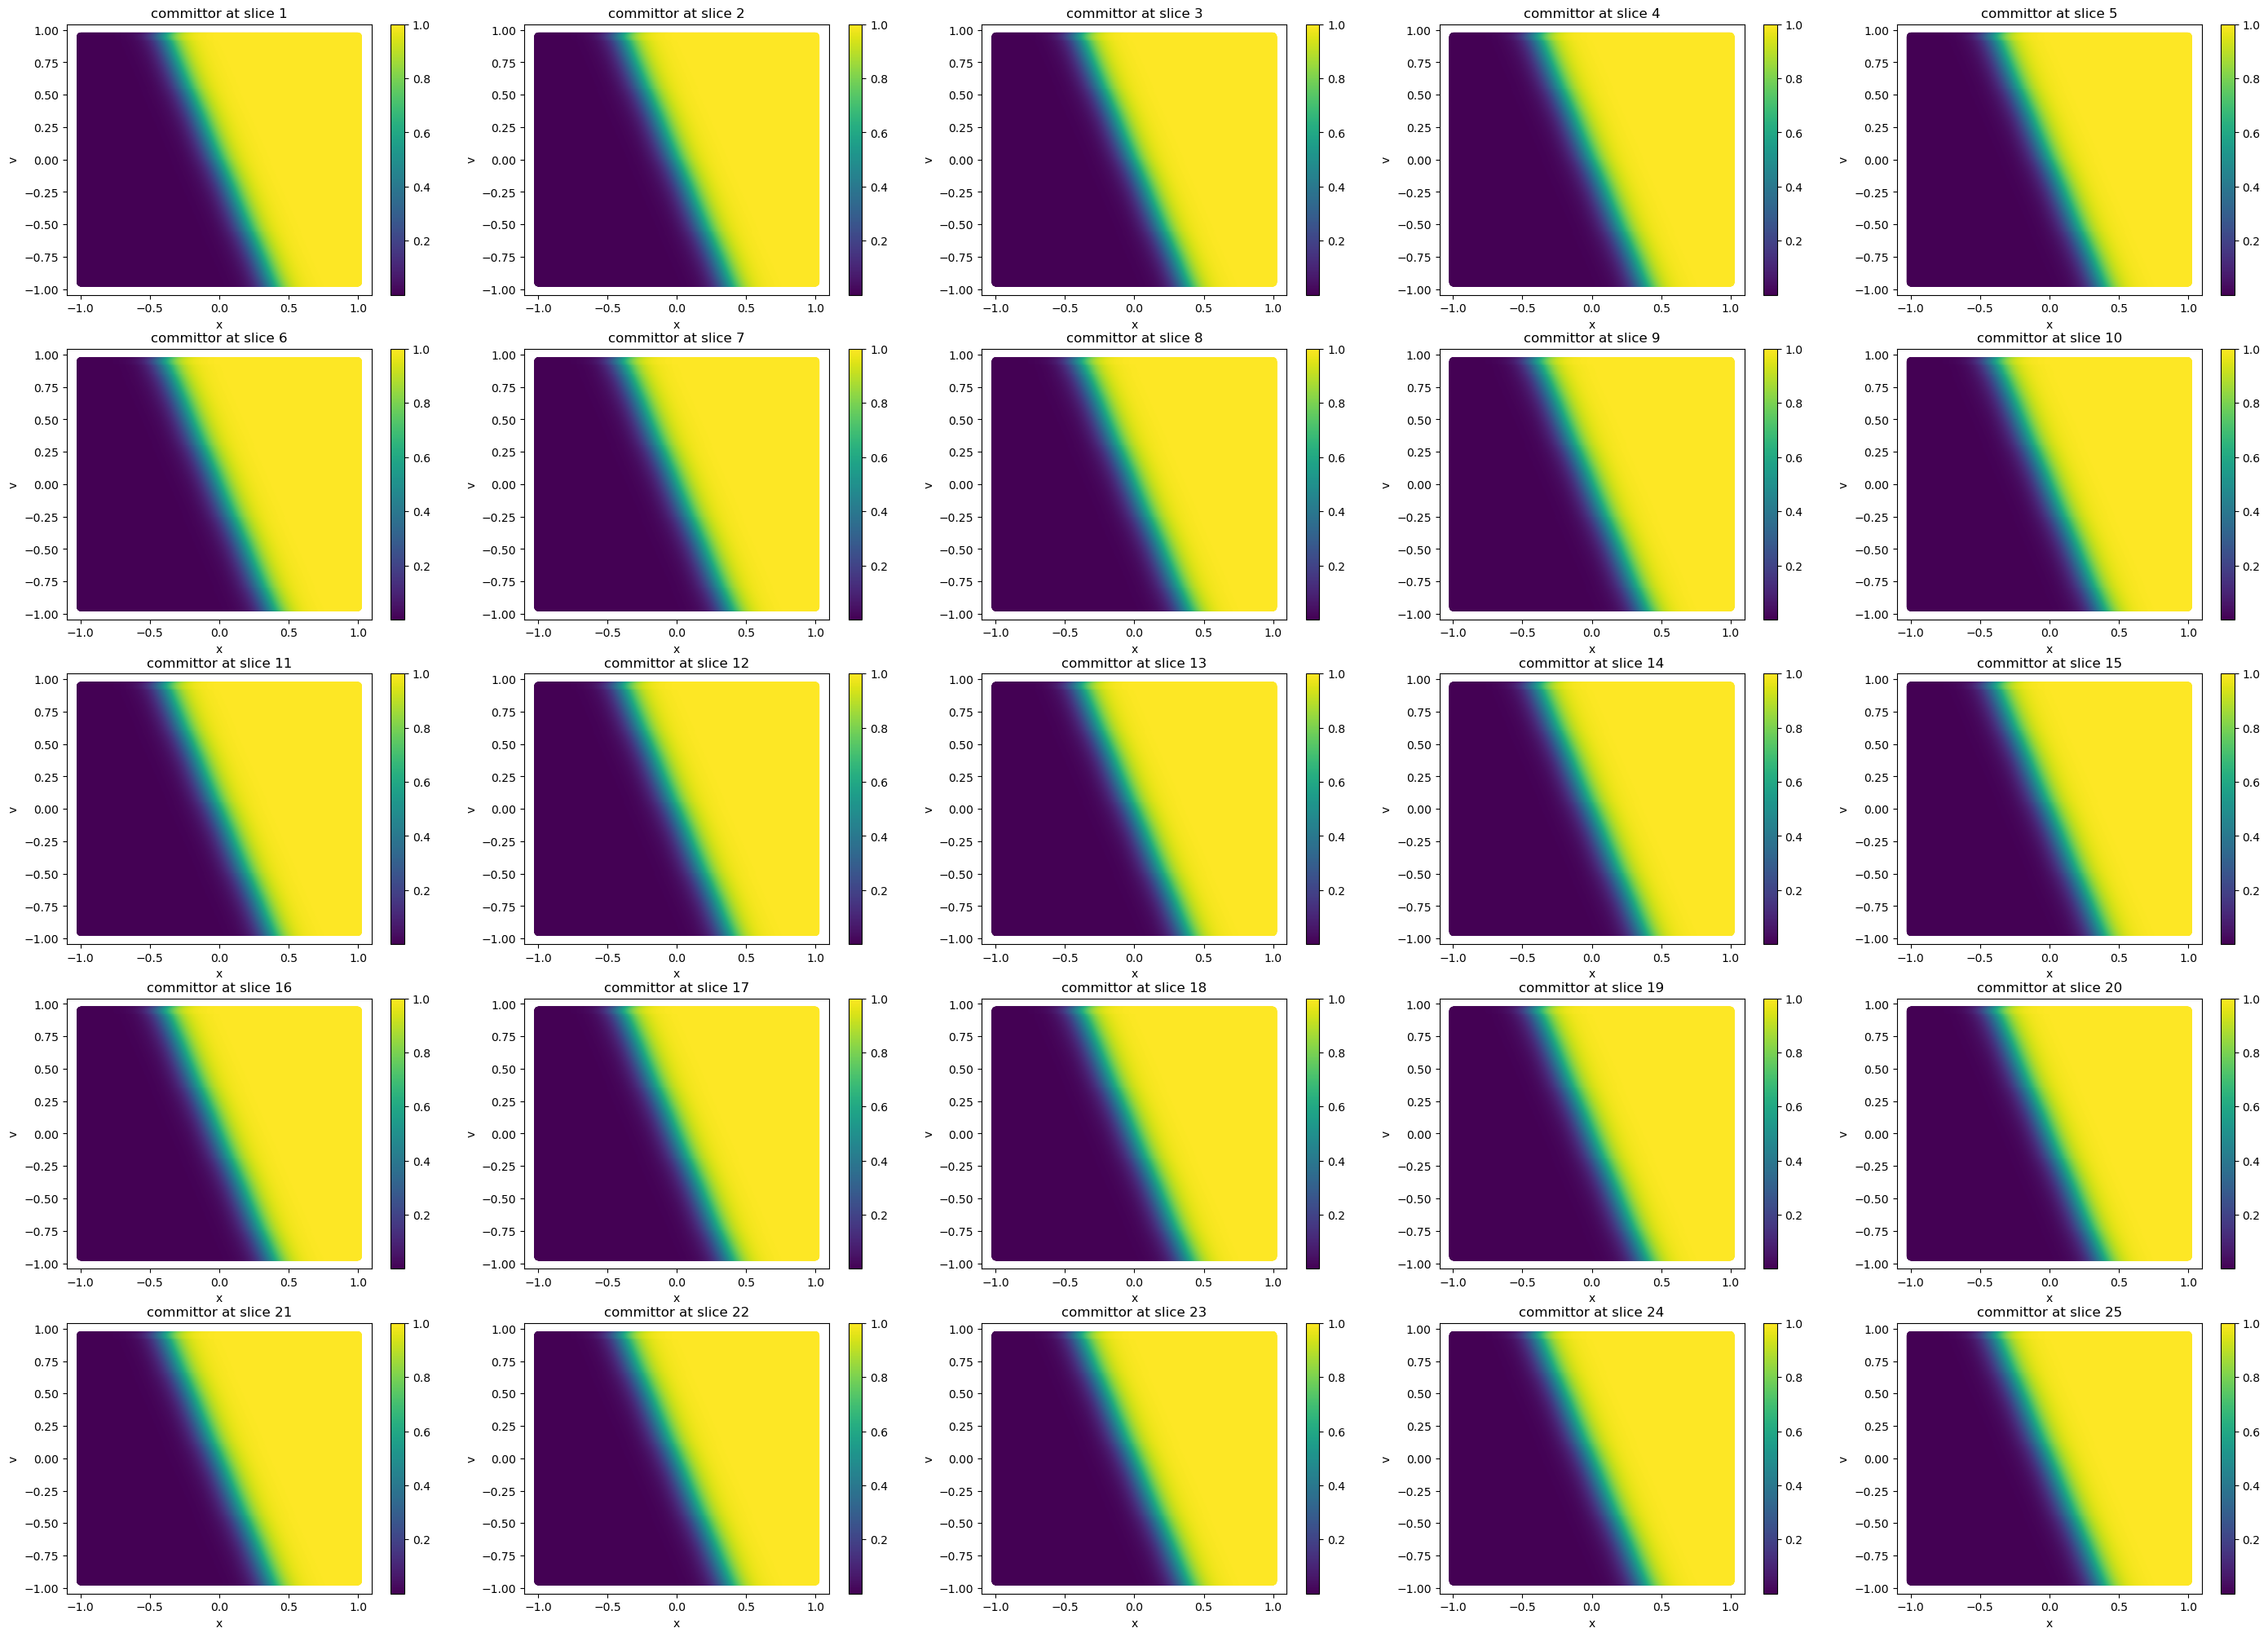

In [ ]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q_adaptive_false.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        print(idx)
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        qqq = q_adaptive_false(ddd).squeeze().to('cpu').detach().numpy() 
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=qqq)  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'committor at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])
        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        l2_loss += np.sum((qqq-fd[:,2])**2*ppp)
        l1_loss += np.sum(np.abs(qqq-fd[:,2])*ppp)
        linf_loss = np.max((np.max(np.abs(qqq-fd[:,2])),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn

print(f'Error for solution with uniform distribution: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')



In [ ]:
mm=5
nn=5
fig, axs = plt.subplots(mm, nn, figsize=(mm*7, nn*5))  
#fig1, axs1 = plt.subplots(mm, nn, figsize=(mm*7, nn*5)) 
q.to(device)
ddd = torch.zeros(size = (fd.shape[0],2*ndim),device = device,dtype = torch.float32)
ddd[:,[0,ndim]] = torch.from_numpy(fd[:,0:2].astype(np.float32)).to(device)
# Generate random data for each subplot  
for i in range(mm):  
    for j in range(nn):  
        idx = j+nn*i
        print(idx)
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim):] = vvm1
        ddd.requires_grad_(True)
        dU1 = potential.gradient(ddd[:,:ndim])
        pinn_l = pinn_loss(q(ddd),ddd,dU1,args)
        pinn_l = pinn_l.detach().cpu().numpy()
        qqq1 = q(ddd).squeeze().to('cpu').detach() 
        '''
        ddd.requires_grad_(False)
        ddd[:,(ndim+1):] = vvms[idx].repeat(fd.shape[0],1)
        ddd[:,1:ndim] = xxms[idx].repeat(fd.shape[0],1)
        dU1 = dU_func(ddd[:,:ndim])
        ddd.requires_grad_(True)
        pinn_l = pinn_loss(q_adaptive_false(ddd),ddd,dU1,args).squeeze().detach().cpu().numpy()
        
        # Create scatter plot  
        sc=axs[i, j].scatter(points[:,0],points[:,1],c=np.abs(pinn_l))  
        #sc1 = axs1[i, j].scatter(points[:,0],points[:,1],c=np.abs(qqq-fd[:,2]))  
        axs[i, j].set_title(f'pinn_loss at slice {idx+1}')  
        axs[i, j].set_xlabel('x')  
        axs[i, j].set_ylabel('v')
        #axs1[i, j].set_title(f'residue at slice {idx+1}')  
        #axs1[i, j].set_xlabel('x')  
        #axs1[i, j].set_ylabel('v')
        fig.colorbar(sc, ax=axs[i,j])
        #fig1.colorbar(sc1, ax=axs1[i,j])
        U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(axis=1)/sigma**2

        HHH = U_func(ddd[:,:ndim]) + 0.5*(ddd[:,ndim:]**2).sum(axis=1)
        HHH = HHH.detach().cpu().numpy()
        ppp = np.exp(-(HHH-np.min(HHH))/kbt)
        ppp = ppp/np.sum(ppp)
        l2_loss += np.sum((pinn_l)**2*ppp)
        l1_loss += np.sum(np.abs(pinn_l)*ppp)
        linf_loss = np.max((np.max(np.abs(pinn_l)),linf_loss))

l2_loss = l2_loss/mm/nn
l2_loss = np.sqrt(l2_loss)
l1_loss = l1_loss/mm/nn

print(f'Pinn loss for solution with uniform distribution: ')
print(f'l2 loss: {l2_loss}, l1 loss: {l1_loss}, linf loss: {linf_loss}')


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
Pinn loss for solution with uniform distribution: 
l2 loss: 0.03444179119695725, l1 loss: 8.64472618881284e-05, linf loss: 0.4446355998516083


MemoryError: Unable to allocate 9.17 MiB for an array with shape (1201399,) and data type float64

<Figure size 3500x2500 with 50 Axes>

In [ ]:

def rate(model,data,weight,args,device,xdim,vdim):
    # data and weight should be sampled from the equilibrium distribution
    data = data.to(device)
    weight = weight.to(device)
    data.requires_grad_(True)
    kbt = args['kbt']
    gamma = args['gamma']

    qqq = model(data)
    with torch.no_grad():
        gradients = torch.autograd.grad(outputs=qqq, inputs=data,
                                    grad_outputs=torch.ones_like(qqq),
                                    create_graph=False, retain_graph=False)[0]
    if weight.shape is not (data.shape[0],1):
        weight = weight.unsqueeze(dim=1)
    grad_v = gradients[:, ndim:]

    return gamma*kbt * torch.sum(weight * (grad_v**2))

In [ ]:
U_func = lambda x: (x[:,0]**2-1)**2 + 0.5*(x[:,1:]**2).sum(dim=1)/sigma**2

w_invariant_valid =  U_func(valid_data[:,:ndim])
w_invariant_valid = w_invariant_valid - torch.min(w_invariant_valid)
w_invariant_valid = torch.exp(-w_invariant_valid/(args['kbt']))
w_invariant_valid = w_invariant_valid/torch.sum(w_invariant_valid)


rate_nn = rate(q,valid_data,w_invariant_valid,args,device,ndim,ndim)
rate_pinn = rate(q_pinn,valid_data,w_invariant_valid,args,device,ndim,ndim)
rate_adaptive_false = rate(q_adaptive_false,valid_data,w_invariant_valid,args,device,ndim,ndim)

print(f'NN rate: {rate_nn.item()}')
print(f'PINN rate: {rate_pinn.item()}')
print(f'Adaptive false rate: {rate_adaptive_false.item()}')

NN rate: 1.216697728523286e-05
PINN rate: 1.246861484105466e-05
Adaptive false rate: 1.2637535292014945e-05
